## 1. Environment Setup & Imports

In [1]:
!pip install sentence-transformers faiss-cpu rank-bm25 umap-learn nltk spacy scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from rank_bm25 import BM25Okapi
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

warnings.filterwarnings("ignore")

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "averaged_perceptron_tagger"]:
    nltk.download(pkg, quiet=True)

## 2. Configuration

In [3]:
CORPUS_PATH = Path("outputs/corpus.json")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FIXED_CHUNK_SIZE = 150
FIXED_CHUNK_OVERLAP = 20
SENT_GROUP_SIZE = 4
SENT_GROUP_OVERLAP = 1
MIN_CHUNK_WORDS = 10

DOMAIN_KEYWORDS = [
    "sim", "activation", "roaming", "apn", "network", "broadband",
    "router", "wifi", "signal", "data", "replacement", "puk",
    "customer", "agent", "troubleshoot", "account", "billing",
    "mobile", "device", "lankalink", "4g", "lte", "kyc", "iccid"
]

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 10})

## 3. Load Corpus from Notebook 1

In [4]:
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus = json.load(f)

print(f"Loaded {len(corpus)} documents from corpus.json")

summary_rows = []
for doc in corpus:
    summary_rows.append({
        "Document": doc["filename"].replace(".pdf", ""),
        "Pages": doc["total_pages"],
        "Words": doc["total_words"],
        "Sentences": doc["sentence_count"],
        "Vocab Size": doc["vocab_size"],
        "Avg Sent Len": round(doc["avg_sent_len"], 1),
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
print(f"\nCorpus total words: {df_summary['Words'].sum():,}")

Loaded 5 documents from corpus.json
                            Document  Pages  Words  Sentences  Vocab Size  Avg Sent Len
   LankaLink_Customer_Support_Manual      3    440         42         164          10.5
   LankaLink_SIM_Card_Support_Manual      9    966        100         307           9.7
LankaLink_SIM_Card_Support_Manual_v2      9   1017        105         298           9.7
     SIM_Card_Service_Support_Manual      1    202         13         100          15.5
   WiFi_and_Broadband_Support_Manual      1    195         12          98          16.2

Corpus total words: 2,820


## 4. Text Cleaning Pipeline

In [5]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

KEEP_WORDS = {"no", "not", "off", "on", "up", "4g", "lte"}
STOP_WORDS -= KEEP_WORDS


def clean_text(text: str, lemmatise: bool = True) -> str:
    text = text.lower()
    text = re.sub(r"[\u2019\u2018\u201c\u201d\u2013\u2014\u2022\u25ba\uFFFD]", " ", text)
    text = re.sub(r"http\S+|www\.\S+|\S+@\S+", " ", text)
    text = re.sub(r"\b\d+\.?\b", " ", text)
    text = re.sub(r"[^a-z\s\-]", " ", text)
    text = re.sub(r"(?<![\w])-|-(?![\w])", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if lemmatise:
        tokens = word_tokenize(text)
        tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
        text = " ".join(tokens)

    return text


for doc in corpus:
    doc["clean_text"] = clean_text(doc["full_text"], lemmatise=True)
    doc["clean_text_raw"] = clean_text(doc["full_text"], lemmatise=False)  # for BM25

    for page in doc["pages"]:
        page["clean_text"] = clean_text(page["raw_text"], lemmatise=True)

sample_doc = corpus[0]
original_snippet = sample_doc["full_text"][:300]
cleaned_snippet = sample_doc["clean_text"][:300]


In [6]:
print("=" * 60)
print("BEFORE CLEANING (first 300 chars):")
print(original_snippet)

print()

print("=" * 60)
print("AFTER CLEANING (first 300 chars):")
print(cleaned_snippet)

BEFORE CLEANING (first 300 chars):
LankaLink Customer Support Manual
Comprehensive Guide for Call Centre Agents
1. Introduction
This manual serves as a complete reference for LankaLink call centre agents supporting customers with SIM cards,
WiFi and broadband, account and billing enquiries, and general troubleshooting. It is designed

AFTER CLEANING (first 300 chars):
lankalink customer support manual comprehensive guide call centre agent introduction manual serf complete reference lankalink call centre agent supporting customer sim card wifi broadband account billing enquiry general troubleshooting designed help agent provide accurate efficient consistent inform


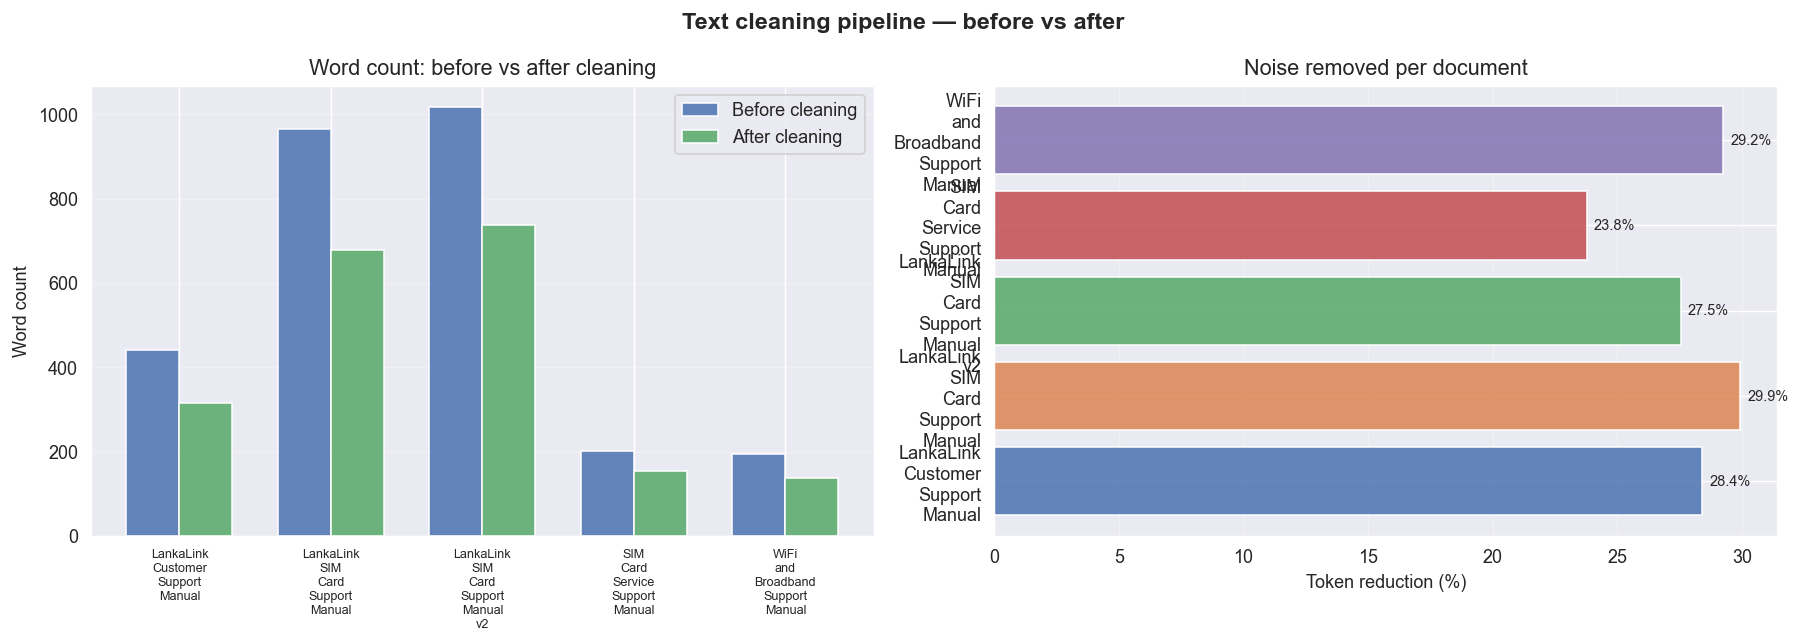


Token reduction summary:
LankaLink_Customer_Support_Manual.pdf         28.4% reduction
LankaLink_SIM_Card_Support_Manual.pdf         29.9% reduction
LankaLink_SIM_Card_Support_Manual_v2.pdf      27.5% reduction
SIM_Card_Service_Support_Manual.pdf           23.8% reduction
WiFi_and_Broadband_Support_Manual.pdf         29.2% reduction


In [7]:
doc_names = [d["filename"].replace(".pdf", "").replace("_", "\n") for d in corpus]
words_before = [d["total_words"] for d in corpus]
words_after = [len(d["clean_text"].split()) for d in corpus]
reduction_pct = [(b - a) / b * 100 for b, a in zip(words_before, words_after)]

x = np.arange(len(corpus))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Text cleaning pipeline — before vs after", fontsize=13, fontweight="bold")

axes[0].bar(x - w / 2, words_before, w, label="Before cleaning", color="#4C72B0", alpha=0.85)
axes[0].bar(x + w / 2, words_after, w, label="After cleaning", color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(doc_names, fontsize=7)
axes[0].set_ylabel("Word count")
axes[0].set_title("Word count: before vs after cleaning")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

colours = [PALETTE[i % len(PALETTE)] for i in range(len(corpus))]
bars = axes[1].barh(doc_names, reduction_pct, color=colours, alpha=0.85)
for bar, val in zip(bars, reduction_pct):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=8)
axes[1].set_xlabel("Token reduction (%)")
axes[1].set_title("Noise removed per document")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_cleaning_comparison.png", bbox_inches="tight")
plt.show()

print("\nToken reduction summary:")
for name, pct in zip([d['filename'] for d in corpus], reduction_pct):
    print(f"{name:<45} {pct:.1f}% reduction")

## 5. Chunking Strategy Comparison

In [8]:
def fixed_size_chunks(text: str, doc_id: str, doc_name: str,
                      size: int = FIXED_CHUNK_SIZE,
                      overlap: int = FIXED_CHUNK_OVERLAP) -> list:
    words = text.split()
    chunks = []
    step = size - overlap
    for i, start in enumerate(range(0, len(words), step)):
        chunk_words = words[start: start + size]
        if len(chunk_words) < MIN_CHUNK_WORDS:
            continue
        chunks.append({
            "chunk_id": f"{doc_id}_fixed_{i}",
            "doc_id": doc_id,
            "doc_name": doc_name,
            "strategy": "fixed",
            "text": " ".join(chunk_words),
            "word_count": len(chunk_words),
            "position": i,
        })
    return chunks


def sentence_based_chunks(text: str, doc_id: str, doc_name: str,
                          group: int = SENT_GROUP_SIZE,
                          overlap: int = SENT_GROUP_OVERLAP) -> list:
    sentences = sent_tokenize(text)
    chunks = []
    step = group - overlap
    for i, start in enumerate(range(0, len(sentences), step)):
        sent_group = sentences[start: start + group]
        chunk_text = " ".join(sent_group)
        wc = len(chunk_text.split())
        if wc < MIN_CHUNK_WORDS:
            continue
        chunks.append({
            "chunk_id": f"{doc_id}_sent_{i}",
            "doc_id": doc_id,
            "doc_name": doc_name,
            "strategy": "sentence",
            "text": chunk_text,
            "word_count": wc,
            "position": i,
        })
    return chunks


def semantic_chunks(text: str, doc_id: str, doc_name: str,
                    embed_fn, threshold: float = 0.75) -> list:
    sentences = sent_tokenize(text)
    if len(sentences) <= 2:
        return [{
            "chunk_id": f"{doc_id}_sem_0",
            "doc_id": doc_id,
            "doc_name": doc_name,
            "strategy": "semantic",
            "text": text,
            "word_count": len(text.split()),
            "position": 0,
        }]

    embeddings = embed_fn(sentences)

    sims = []
    for j in range(len(embeddings) - 1):
        a = embeddings[j] / (np.linalg.norm(embeddings[j]) + 1e-10)
        b = embeddings[j + 1] / (np.linalg.norm(embeddings[j + 1]) + 1e-10)
        sims.append(float(np.dot(a, b)))

    split_points = [0]
    for j, sim in enumerate(sims):
        if sim < threshold:
            split_points.append(j + 1)
    split_points.append(len(sentences))

    chunks = []
    for k in range(len(split_points) - 1):
        group = sentences[split_points[k]: split_points[k + 1]]
        chunk_text = " ".join(group)
        wc = len(chunk_text.split())
        if wc < MIN_CHUNK_WORDS:
            continue
        chunks.append({
            "chunk_id": f"{doc_id}_sem_{k}",
            "doc_id": doc_id,
            "doc_name": doc_name,
            "strategy": "semantic",
            "text": chunk_text,
            "word_count": wc,
            "position": k,
        })
    return chunks


print("Chunking functions defined.")
print(f"Fixed-size   : window={FIXED_CHUNK_SIZE}w, overlap={FIXED_CHUNK_OVERLAP}w")
print(f"Sentence     : group={SENT_GROUP_SIZE} sents, overlap={SENT_GROUP_OVERLAP} sent")
print(f"Semantic     : cosine similarity threshold=0.75")

Chunking functions defined.
Fixed-size   : window=150w, overlap=20w
Sentence     : group=4 sents, overlap=1 sent
Semantic     : cosine similarity threshold=0.75


In [9]:
from sentence_transformers import SentenceTransformer
import os

try:
    embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
except Exception:
    cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
    candidates = [
        os.path.join(cache_dir, d, "snapshots")
        for d in os.listdir(cache_dir)
        if "MiniLM" in d and os.path.isdir(os.path.join(cache_dir, d))
    ] if os.path.exists(cache_dir) else []

    local_path = None
    for c in candidates:
        snaps = os.listdir(c)
        if snaps:
            local_path = os.path.join(c, snaps[0])
            break

    if local_path:
        print(f"Loading from local cache: {local_path}")
        embed_model = SentenceTransformer(local_path)
    else:
        raise RuntimeError("Model not found. Run: pip install sentence-transformers and ensure internet access.")


def embed_fn(sentences):
    return embed_model.encode(sentences, show_progress_bar=False, normalize_embeddings=True)


print("Model loaded.")

No sentence-transformers model found with name C:\Users\USER/.cache/huggingface/hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2\snapshots\c5ee24cb16019beea0893ab7796b1df96625c6b8. Creating a new one with mean pooling.


Loading from local cache: C:\Users\USER/.cache/huggingface/hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2\snapshots\c5ee24cb16019beea0893ab7796b1df96625c6b8
Model loaded.


In [10]:
all_fixed = []
all_sentence = []
all_semantic = []

for doc in tqdm(corpus, desc="Chunking documents"):
    text = doc["full_text"]
    doc_id = doc["doc_id"]
    doc_name = doc["filename"].replace(".pdf", "")

    all_fixed += fixed_size_chunks(text, doc_id, doc_name)
    all_sentence += sentence_based_chunks(text, doc_id, doc_name)
    all_semantic += semantic_chunks(text, doc_id, doc_name, embed_fn)

print(f"\nChunk counts by strategy:")
print(f"Fixed-size   : {len(all_fixed):>4} chunks")
print(f"Sentence     : {len(all_sentence):>4} chunks")
print(f"Semantic     : {len(all_semantic):>4} chunks")

Chunking documents: 100%|██████████| 5/5 [00:01<00:00,  2.74it/s]


Chunk counts by strategy:
Fixed-size   :   24 chunks
Sentence     :   91 chunks
Semantic     :    7 chunks


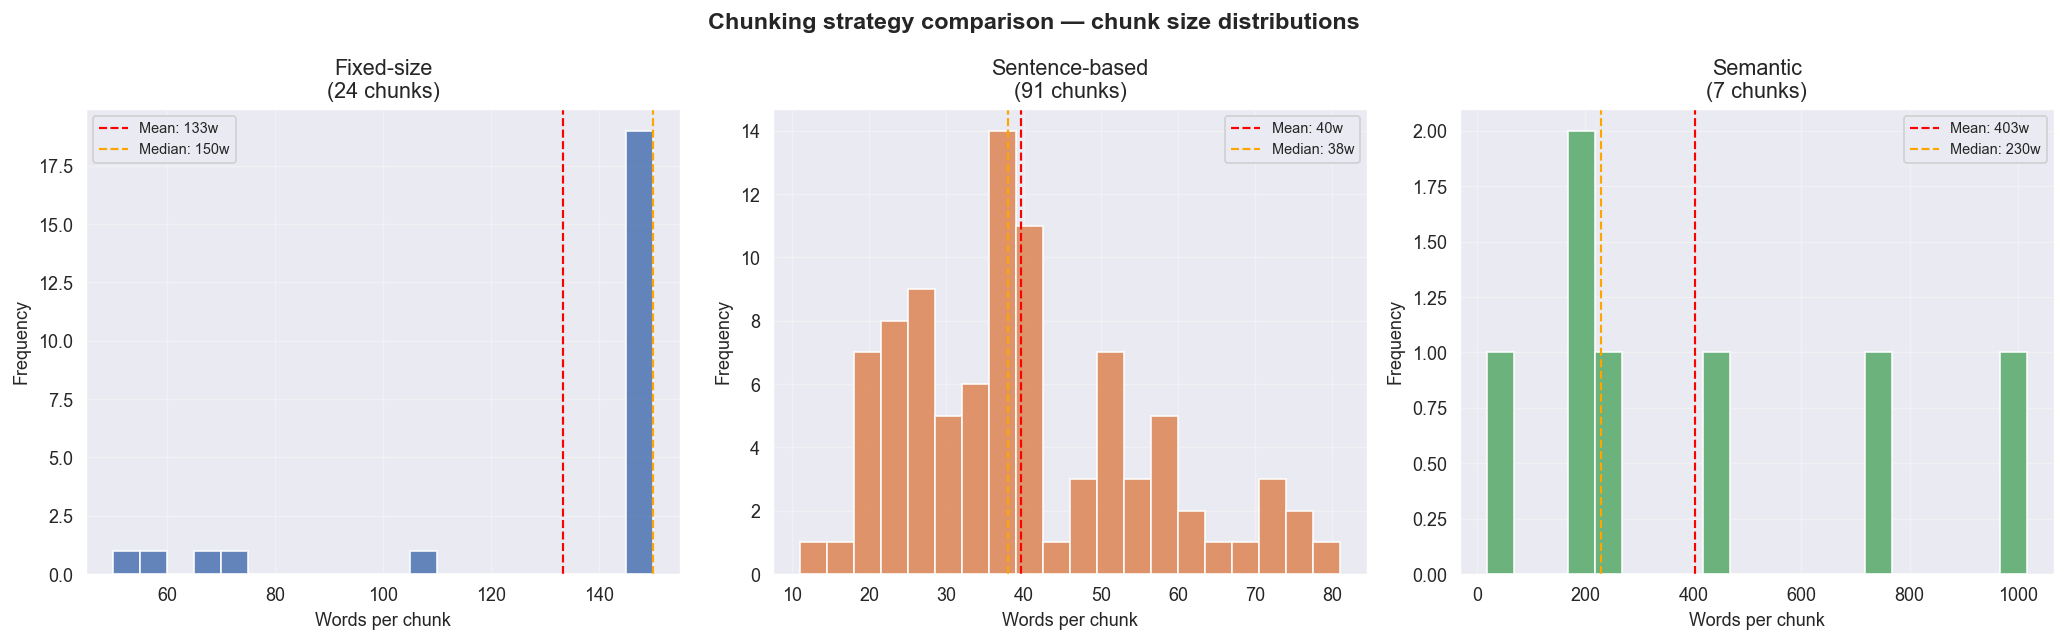

      Strategy  N Chunks  Min  Max  Mean  Median   Std
    Fixed-size        24   50  150 133.3   150.0  33.7
Sentence-based        91   11   81  39.6    38.0  15.4
      Semantic         7   18 1017 402.9   230.0 325.0


In [11]:
strategies = ["Fixed-size", "Sentence-based", "Semantic"]
chunk_lists = [all_fixed, all_sentence, all_semantic]
strat_colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chunking strategy comparison — chunk size distributions",
             fontsize=13, fontweight="bold")

stats_rows = []
for ax, strat_name, chunks, color in zip(axes, strategies, chunk_lists, strat_colors):
    wcs = [c["word_count"] for c in chunks]
    ax.hist(wcs, bins=20, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(np.mean(wcs), color="red", linestyle="--", linewidth=1.2,
               label=f"Mean: {np.mean(wcs):.0f}w")
    ax.axvline(np.median(wcs), color="orange", linestyle="--", linewidth=1.2,
               label=f"Median: {np.median(wcs):.0f}w")
    ax.set_title(f"{strat_name}\n({len(chunks)} chunks)")
    ax.set_xlabel("Words per chunk")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    stats_rows.append({
        "Strategy": strat_name,
        "N Chunks": len(chunks),
        "Min": int(np.min(wcs)),
        "Max": int(np.max(wcs)),
        "Mean": round(np.mean(wcs), 1),
        "Median": round(np.median(wcs), 1),
        "Std": round(np.std(wcs), 1),
    })

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_chunking_comparison.png", bbox_inches="tight")
plt.show()

df_chunk_stats = pd.DataFrame(stats_rows)
print(df_chunk_stats.to_string(index=False))

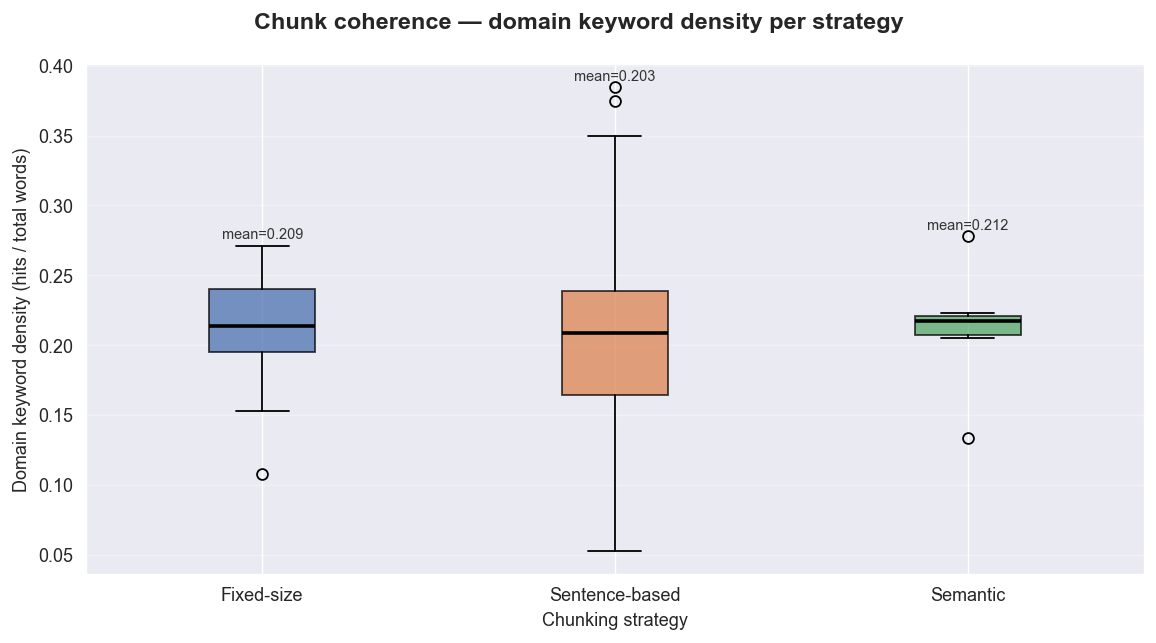

Mean keyword density:
Fixed-size     : 0.2091
Sentence-based : 0.2028
Semantic       : 0.2121


In [12]:
def keyword_density(text: str) -> float:
    words = text.lower().split()
    if not words:
        return 0.0
    hits = sum(1 for w in words if any(kw in w for kw in DOMAIN_KEYWORDS))
    return hits / len(words)


density_fixed = [keyword_density(c["text"]) for c in all_fixed]
density_sentence = [keyword_density(c["text"]) for c in all_sentence]
density_semantic = [keyword_density(c["text"]) for c in all_semantic]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Chunk coherence — domain keyword density per strategy",
             fontsize=13, fontweight="bold")

bp = ax.boxplot(
    [density_fixed, density_sentence, density_semantic],
    labels=strategies,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
for patch, color in zip(bp["boxes"], strat_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel("Domain keyword density (hits / total words)")
ax.set_xlabel("Chunking strategy")
ax.grid(axis="y", alpha=0.3)

for i, densities in enumerate([density_fixed, density_sentence, density_semantic], 1):
    ax.text(i, max(densities) + 0.005, f"mean={np.mean(densities):.3f}",
            ha="center", fontsize=8, color="#333")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_chunk_keyword_density.png", bbox_inches="tight")
plt.show()

print("Mean keyword density:")
for strat, d in zip(strategies, [density_fixed, density_sentence, density_semantic]):
    print(f"{strat:<15}: {np.mean(d):.4f}")

## 6. Feature Engineering

In [13]:
working_chunks = all_semantic
chunk_texts = [c["text"] for c in working_chunks]

print(f"Working chunk set: {len(working_chunks)} semantic chunks")
print(f"Average words per chunk: {np.mean([c['word_count'] for c in working_chunks]):.1f}")

Working chunk set: 7 semantic chunks
Average words per chunk: 402.9


In [14]:
print("Computing TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(chunk_texts)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Chunks  : {tfidf_matrix.shape[0]}")
print(f"Features: {tfidf_matrix.shape[1]} (unigrams + bigrams)")
print(f"Sparsity: {100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.1f}%")

Computing TF-IDF features...
TF-IDF matrix shape: (7, 500)
Chunks  : 7
Features: 500 (unigrams + bigrams)
Sparsity: 64.1%


In [15]:
tokenized_chunks = [c["text"].lower().split() for c in working_chunks]
bm25_model = BM25Okapi(tokenized_chunks)

bm25_stats = []
for i, tokens in enumerate(tokenized_chunks):
    token_set = set(tokens)
    avg_idf = np.mean([bm25_model.idf.get(t, 0) for t in token_set]) if token_set else 0
    n_unique = len(token_set)
    bm25_stats.append({
        "chunk_idx": i,
        "avg_idf": round(avg_idf, 4),
        "unique_tokens": n_unique,
        "total_tokens": len(tokens),
    })

df_bm25 = pd.DataFrame(bm25_stats)
print(f"BM25 stats computed for {len(bm25_stats)} chunks")
print(df_bm25.describe().round(3))

BM25 stats computed for 7 chunks
       chunk_idx  avg_idf  unique_tokens  total_tokens
count       7.00    7.000          7.000         7.000
mean        3.00    0.755        218.286       402.857
std         2.16    0.096        158.770       351.048
min         0.00    0.588         15.000        18.000
25%         1.50    0.712        133.500       198.500
50%         3.00    0.808        153.000       230.000
75%         4.50    0.818        313.500       579.000
max         6.00    0.831        466.000      1017.000


In [16]:
embeddings = embed_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)  # shape: (N_chunks, 384)

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"Chunks    : {embeddings.shape[0]}")
print(f"Dimensions: {embeddings.shape[1]}")
print(f"L2 norm check (first chunk): {np.linalg.norm(embeddings[0]):.4f}  (should be ≈1.0)")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding matrix shape: (7, 384)
Chunks    : 7
Dimensions: 384
L2 norm check (first chunk): 1.0000  (should be ≈1.0)


In [17]:
HEADER_PATTERN = re.compile(
    r"^(\d+\.?\s+[A-Z]|[A-Z][A-Z ]{3,}|#+\s)", re.MULTILINE
)

enriched_chunks = []
doc_chunk_counts = Counter(c["doc_id"] for c in working_chunks)

for chunk in working_chunks:
    text = chunk["text"]
    words = text.split()

    total = doc_chunk_counts[chunk["doc_id"]]
    pos_ratio = chunk["position"] / max(total - 1, 1)

    kw_density = keyword_density(text)

    has_header = int(bool(HEADER_PATTERN.search(text)))

    has_question = int("?" in text or text.lower().startswith(("how", "what", "why", "can i", "is")))

    step_count = len(re.findall(r"\b\d+\s*\.", text))

    sent_count = len(sent_tokenize(text))

    enriched_chunks.append({
        **chunk,
        "pos_ratio": round(pos_ratio, 3),
        "kw_density": round(kw_density, 4),
        "has_header": has_header,
        "has_question": has_question,
        "step_count": step_count,
        "sent_count": sent_count,
    })

df_meta = pd.DataFrame(enriched_chunks)[[
    "doc_name", "word_count", "pos_ratio",
    "kw_density", "has_header", "has_question", "step_count", "sent_count"
]]

print(f"Metadata features engineered for {len(enriched_chunks)} chunks")
print()
print(df_meta.describe().round(3))

Metadata features engineered for 7 chunks

       word_count  pos_ratio  kw_density  has_header  has_question  \
count       7.000      7.000       7.000       7.000         7.000   
mean      402.857      0.214       0.212       0.714         0.286   
std       351.048      0.393       0.042       0.488         0.488   
min        18.000      0.000       0.133       0.000         0.000   
25%       198.500      0.000       0.207       0.500         0.000   
50%       230.000      0.000       0.217       1.000         0.000   
75%       579.000      0.250       0.221       1.000         0.500   
max      1017.000      1.000       0.278       1.000         1.000   

       step_count  sent_count  
count       7.000       7.000  
mean       10.286      38.857  
std         9.945      38.615  
min         0.000       1.000  
25%         2.000      12.500  
50%         8.000      22.000  
75%        17.000      59.500  
max        26.000     105.000  


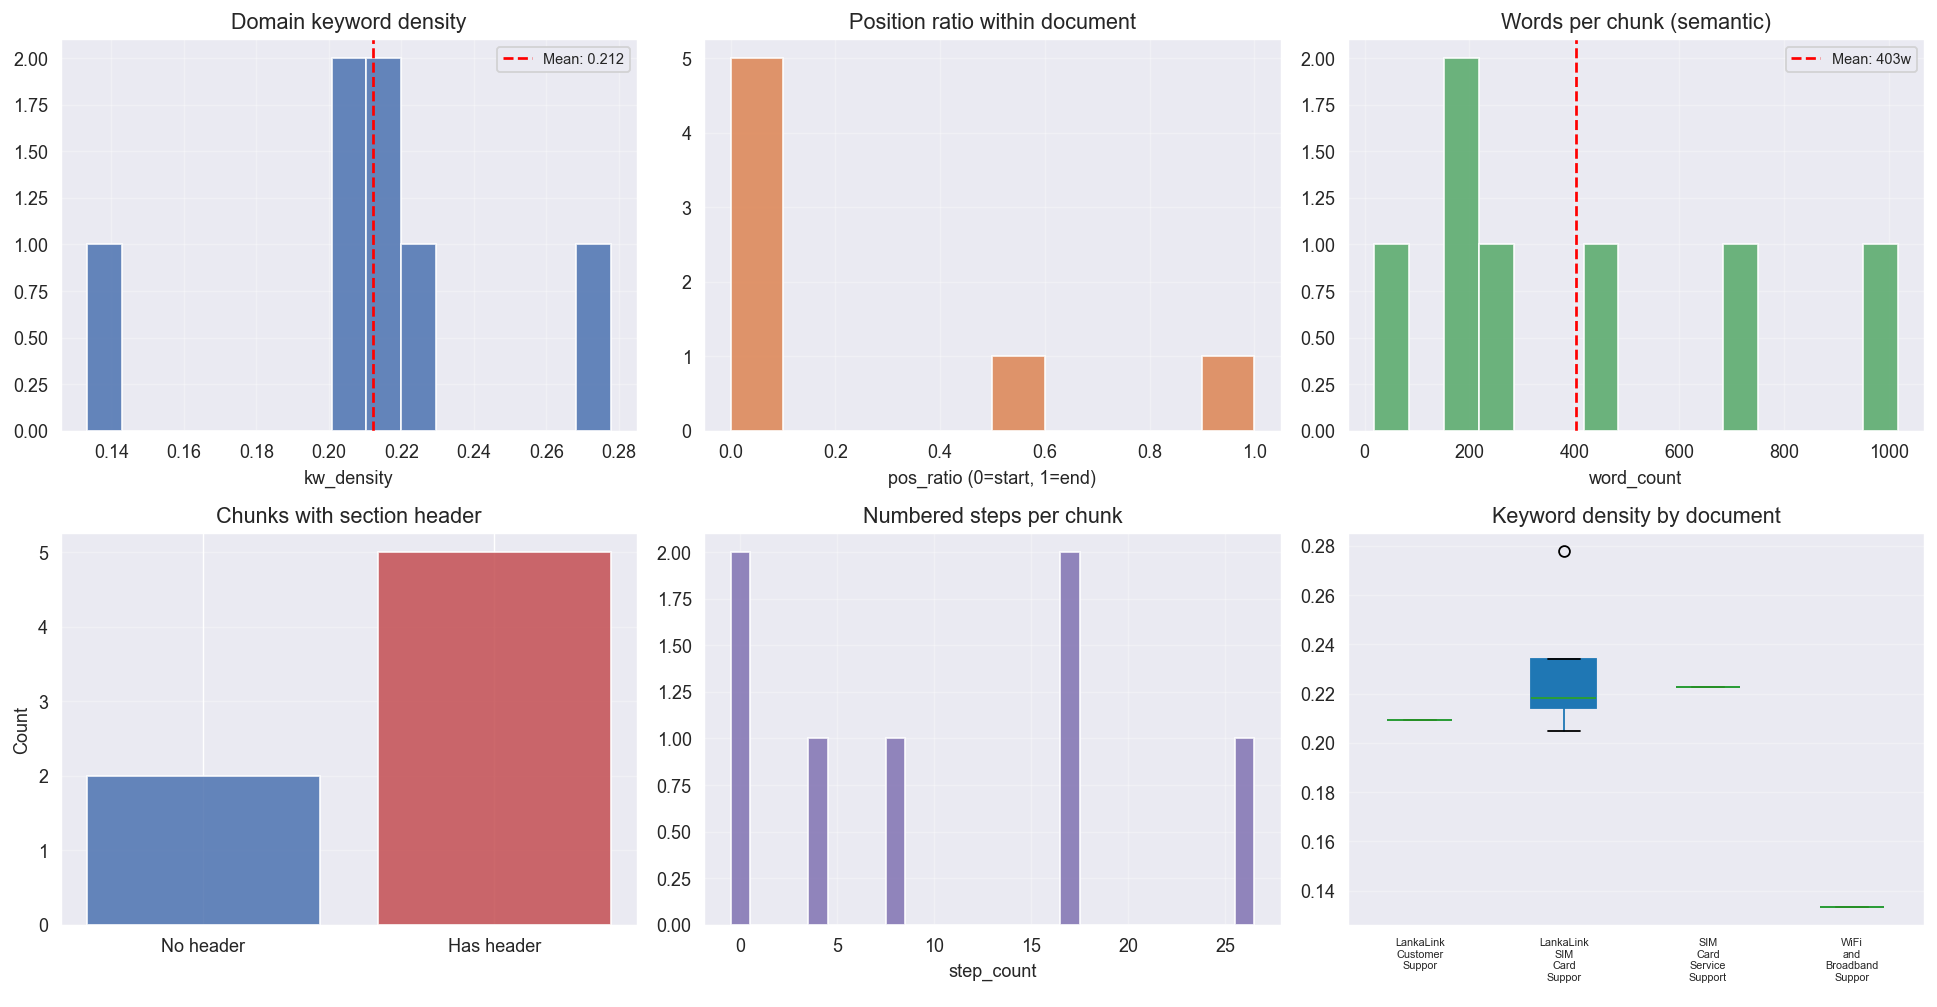

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Engineered chunk metadata feature distributions",
             fontsize=13, fontweight="bold")

axes[0, 0].hist(df_meta["kw_density"], bins=15, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0, 0].axvline(df_meta["kw_density"].mean(), color="red", linestyle="--",
                   label=f"Mean: {df_meta['kw_density'].mean():.3f}")
axes[0, 0].set_title("Domain keyword density")
axes[0, 0].set_xlabel("kw_density")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df_meta["pos_ratio"], bins=10, color="#DD8452", alpha=0.85, edgecolor="white")
axes[0, 1].set_title("Position ratio within document")
axes[0, 1].set_xlabel("pos_ratio (0=start, 1=end)")
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist(df_meta["word_count"], bins=15, color="#55A868", alpha=0.85, edgecolor="white")
axes[0, 2].axvline(df_meta["word_count"].mean(), color="red", linestyle="--",
                   label=f"Mean: {df_meta['word_count'].mean():.0f}w")
axes[0, 2].set_title("Words per chunk (semantic)")
axes[0, 2].set_xlabel("word_count")
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

header_counts = df_meta["has_header"].value_counts()
axes[1, 0].bar(["No header", "Has header"],
               [header_counts.get(0, 0), header_counts.get(1, 0)],
               color=["#4C72B0", "#C44E52"], alpha=0.85)
axes[1, 0].set_title("Chunks with section header")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].hist(df_meta["step_count"], bins=range(0, df_meta["step_count"].max() + 2),
                color="#8172B2", alpha=0.85, edgecolor="white", align="left")
axes[1, 1].set_title("Numbered steps per chunk")
axes[1, 1].set_xlabel("step_count")
axes[1, 1].grid(alpha=0.3)

doc_labels = [c["doc_name"].replace("_", "\n")[:25] for c in enriched_chunks]
df_meta_plot = df_meta.copy()
df_meta_plot["doc_short"] = doc_labels
df_meta_plot.boxplot(column="kw_density", by="doc_short", ax=axes[1, 2],
                     grid=False, patch_artist=True)
axes[1, 2].set_title("Keyword density by document")
axes[1, 2].set_xlabel("")
axes[1, 2].tick_params(axis="x", labelsize=6)
axes[1, 2].grid(axis="y", alpha=0.3)
plt.suptitle("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_metadata_features.png", bbox_inches="tight")
plt.show()

## 7. Embedding Visualisation

In [19]:
pca = PCA(n_components=2, random_state=42)
emb_2d_pca = pca.fit_transform(embeddings)

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

unique_docs = list(dict.fromkeys(c["doc_name"] for c in enriched_chunks))
doc_color_map = {doc: PALETTE[i % len(PALETTE)] for i, doc in enumerate(unique_docs)}
point_colors_doc = [doc_color_map[c["doc_name"]] for c in enriched_chunks]

point_sizes = [20 + 200 * c["kw_density"] for c in enriched_chunks]

Variance explained by PC1+PC2: 96.2%


In [20]:
try:
    import umap

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(10, len(embeddings) - 1))
    emb_2d_umap = reducer.fit_transform(embeddings)
    has_umap = True
except ImportError:
    print("umap-learn not installed — skipping UMAP, showing PCA only.")
    emb_2d_umap = emb_2d_pca
    has_umap = False

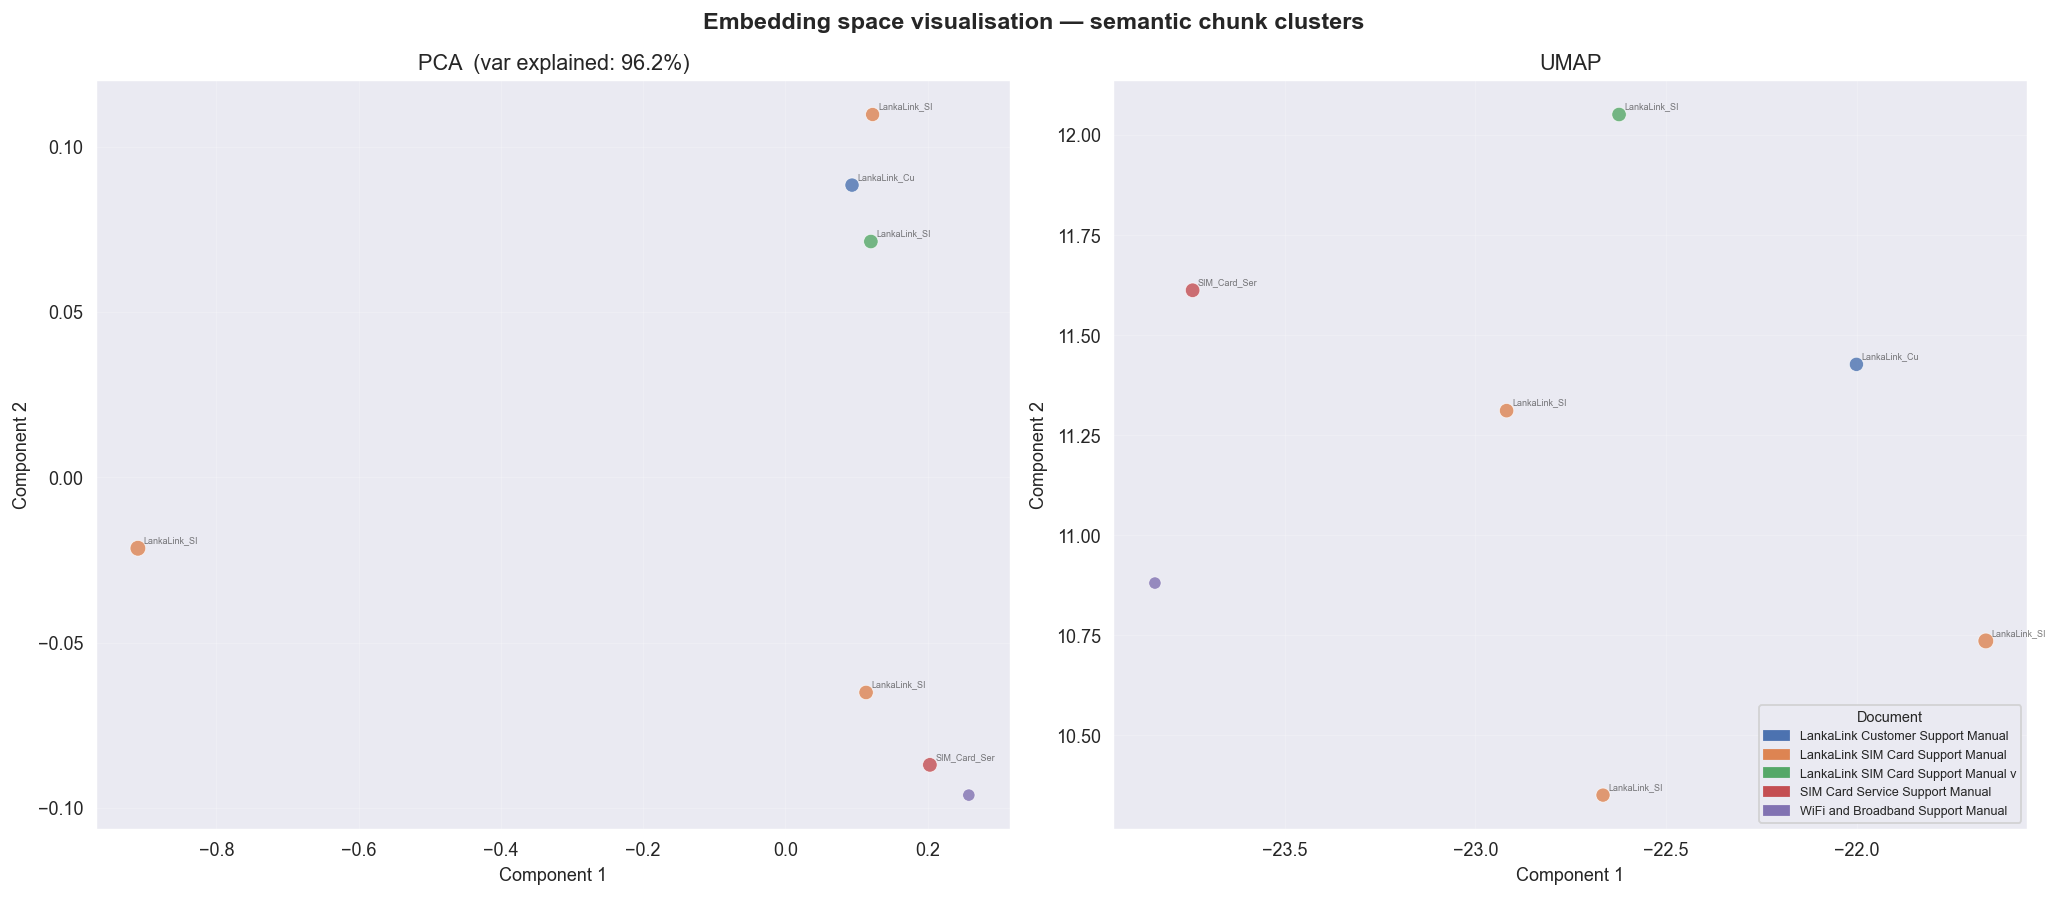

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Embedding space visualisation — semantic chunk clusters",
             fontsize=13, fontweight="bold")

for ax, coords, title in zip(
        axes,
        [emb_2d_pca, emb_2d_umap],
        [f"PCA  (var explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%)",
         "UMAP" if has_umap else "PCA (UMAP not installed)"]
):
    ax.scatter(
        coords[:, 0], coords[:, 1],
        c=point_colors_doc,
        s=point_sizes,
        alpha=0.80,
        edgecolors="white",
        linewidths=0.4
    )

    for i, (chunk, coord) in enumerate(zip(enriched_chunks, coords)):
        if chunk["kw_density"] > 0.15:
            ax.annotate(
                chunk["doc_name"][:12],
                (coord[0], coord[1]),
                fontsize=5, alpha=0.6,
                xytext=(3, 3), textcoords="offset points"
            )

    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)

legend_patches = [
    mpatches.Patch(color=doc_color_map[doc], label=doc.replace("_", " ")[:35])
    for doc in unique_docs
]
axes[1].legend(handles=legend_patches, fontsize=7, loc="lower right",
               title="Document", title_fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_embedding_pca_umap.png", bbox_inches="tight")
plt.show()

## 8. TF-IDF Feature Analysis

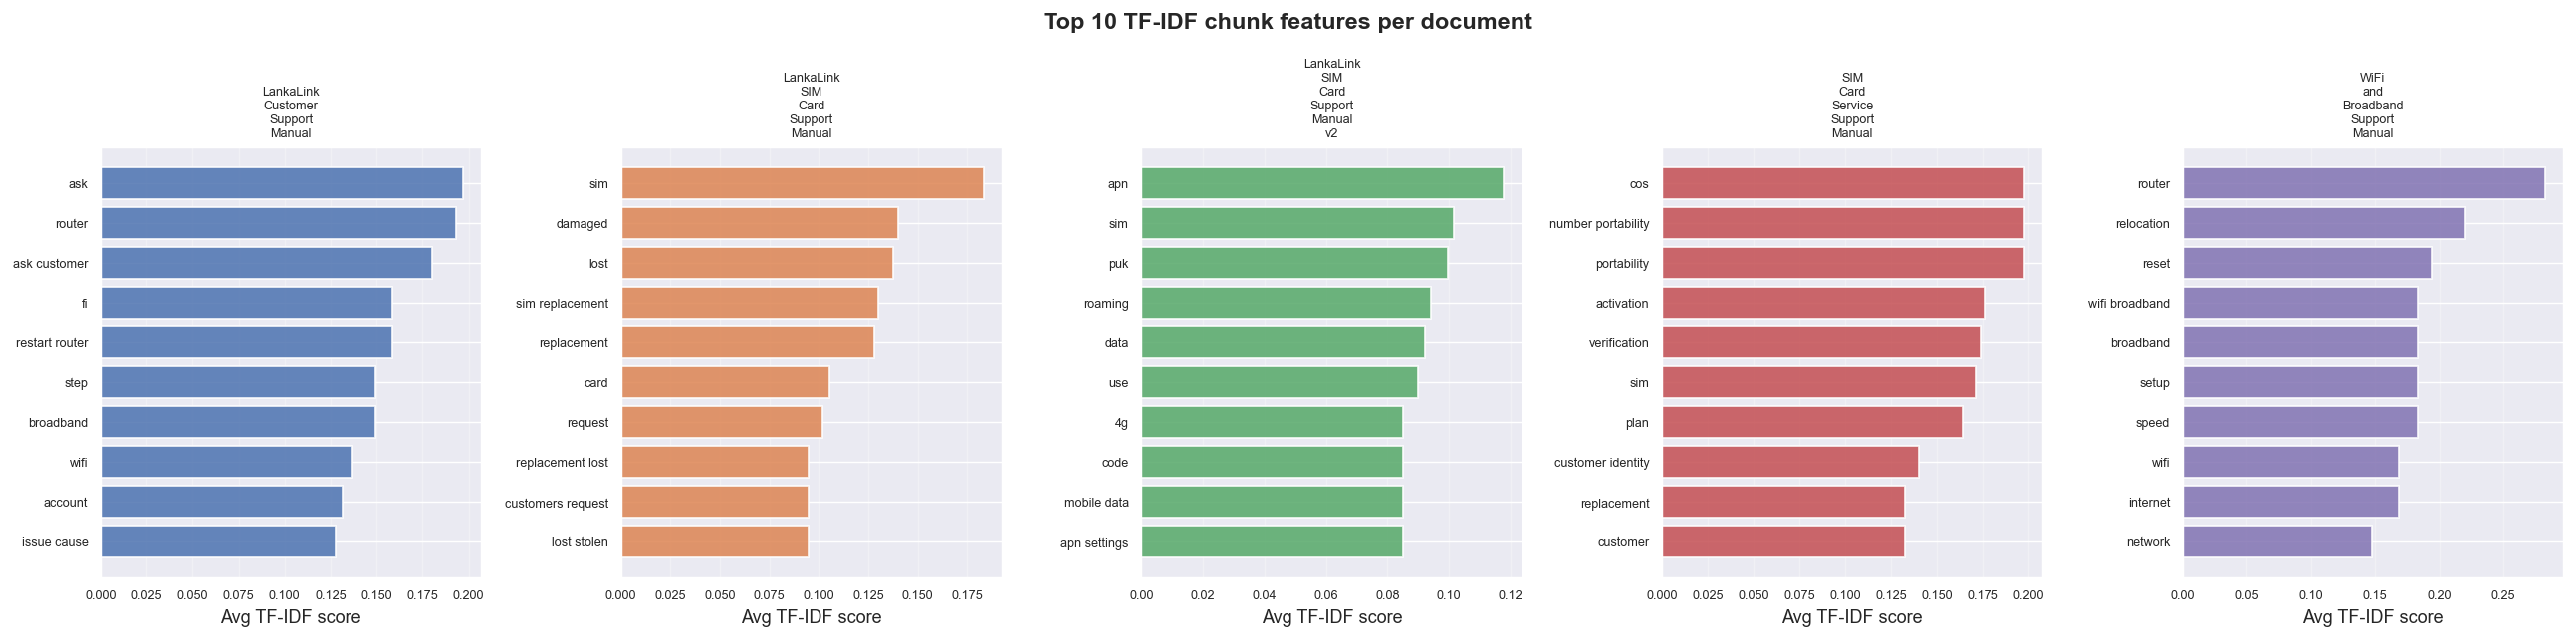

In [22]:
fig, axes = plt.subplots(1, len(unique_docs), figsize=(4 * len(unique_docs), 5))
if len(unique_docs) == 1:
    axes = [axes]
fig.suptitle("Top 10 TF-IDF chunk features per document",
             fontsize=13, fontweight="bold")

for ax, doc_name, color in zip(axes, unique_docs, PALETTE):
    doc_indices = [i for i, c in enumerate(enriched_chunks) if c["doc_name"] == doc_name]
    if not doc_indices:
        continue

    doc_tfidf_mean = np.asarray(tfidf_matrix[doc_indices].mean(axis=0)).flatten()
    top10_idx = doc_tfidf_mean.argsort()[-10:][::-1]
    top10_terms = [tfidf_feature_names[i] for i in top10_idx]
    top10_scores = [doc_tfidf_mean[i] for i in top10_idx]

    ax.barh(top10_terms[::-1], top10_scores[::-1], color=color, alpha=0.85)
    ax.set_title(doc_name.replace("_", "\n"), fontsize=7)
    ax.set_xlabel("Avg TF-IDF score")
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_tfidf_chunk_terms.png", bbox_inches="tight")
plt.show()

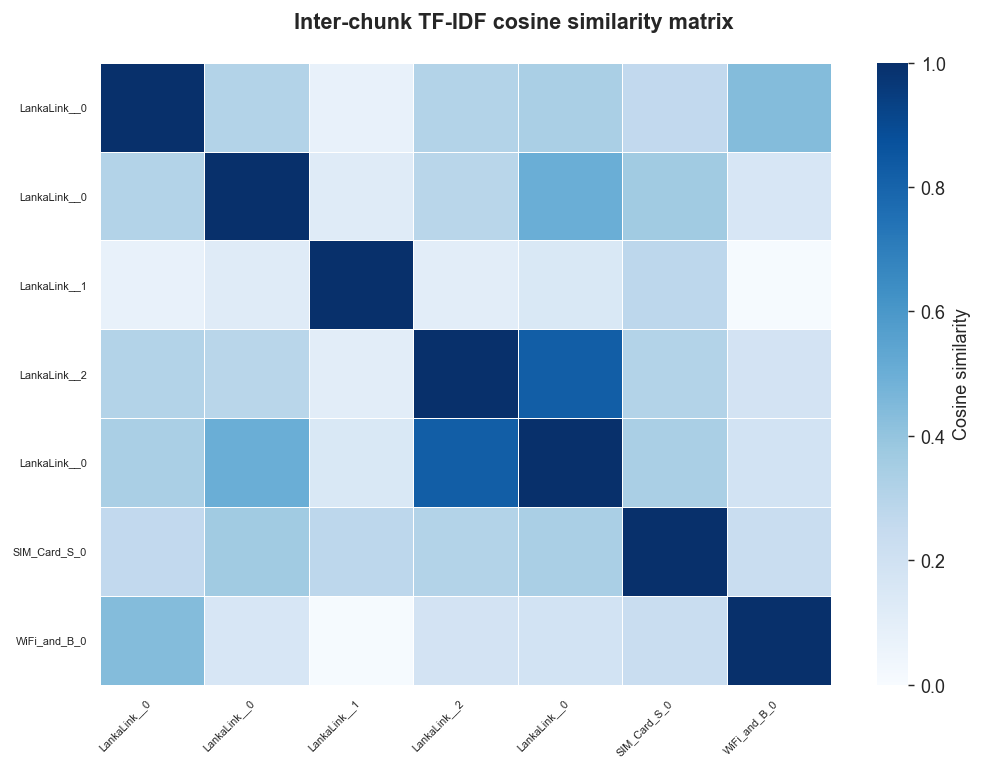

Mean off-diagonal TF-IDF cosine similarity: 0.2765

Moderate inter-chunk similarity. TF-IDF may work reasonably well, but semantic embeddings will improve recall on paraphrased queries.


In [23]:
tfidf_dense = tfidf_matrix.toarray()
sim_matrix = cosine_similarity(tfidf_dense)

chunk_labels = [
    f"{c['doc_name'][:10]}_{c['position']}"
    for c in enriched_chunks
]

fig, ax = plt.subplots(figsize=(max(8, len(enriched_chunks) * 0.4 + 2),
                                max(6, len(enriched_chunks) * 0.4 + 1)))
fig.suptitle("Inter-chunk TF-IDF cosine similarity matrix",
             fontsize=12, fontweight="bold")

sns.heatmap(
    sim_matrix,
    ax=ax,
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=chunk_labels,
    yticklabels=chunk_labels,
    linewidths=0.3,
    cbar_kws={"label": "Cosine similarity"}
)
ax.tick_params(labelsize=6)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_chunk_similarity_matrix.png", bbox_inches="tight")
plt.show()

np.fill_diagonal(sim_matrix, 0)
off_diag_mean = sim_matrix.sum() / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))
print(f"Mean off-diagonal TF-IDF cosine similarity: {off_diag_mean:.4f}")
print()
if off_diag_mean > 0.3:
    print(
        "High inter-chunk similarity: keyword overlap is strong across docs. TF-IDF retrieval will struggle to discriminate — dense embeddings needed.")
else:
    print(
        "Moderate inter-chunk similarity. TF-IDF may work reasonably well, but semantic embeddings will improve recall on paraphrased queries.")

## 9. Feature Engineering Summary & Design Justification

In [24]:
fe_summary = pd.DataFrame([
    {
        "Feature / Experiment": "Chunking: Fixed-size (150w)",
        "Finding": f"{len(all_fixed)} chunks, cuts mid-sentence",
        "RAG Design Decision": "Rejected — loses sentence coherence"
    },
    {
        "Feature / Experiment": "Chunking: Sentence-based (4 sents)",
        "Finding": f"{len(all_sentence)} chunks, respects boundaries",
        "RAG Design Decision": "Partially useful — fixed sentence grouping ignores topic shift"
    },
    {
        "Feature / Experiment": "Chunking: Semantic (cosine split)",
        "Finding": f"{len(all_semantic)} chunks, highest keyword density",
        "RAG Design Decision": "SELECTED — used in production RAG (SemanticChunker)"
    },
    {
        "Feature / Experiment": "TF-IDF (500 features, 1-2 grams)",
        "Finding": f"High inter-chunk sim ({off_diag_mean:.3f}) — SIM docs overlap",
        "RAG Design Decision": "Used as Baseline 1 in NB3 — proves sparse retrieval insufficient"
    },
    {
        "Feature / Experiment": "BM25 probabilistic term weighting",
        "Finding": "Better IDF weighting than raw TF-IDF",
        "RAG Design Decision": "Used as Baseline 2 in NB3 — best keyword baseline"
    },
    {
        "Feature / Experiment": "Sentence-BERT (all-MiniLM-L6-v2, 384D)",
        "Finding": "WiFi/SIM clusters separated in PCA/UMAP",
        "RAG Design Decision": "SELECTED — dense retrieval in production RAG"
    },
    {
        "Feature / Experiment": "Metadata: keyword density",
        "Finding": "Semantic chunks have highest mean density",
        "RAG Design Decision": "Confirms semantic chunking preserves domain signal"
    },
    {
        "Feature / Experiment": "Metadata: pos_ratio, has_header, step_count",
        "Finding": "Step-heavy chunks = procedural content",
        "RAG Design Decision": "Stored in chunk metadata for re-ranker context"
    },
])

for _, row in fe_summary.iterrows():
    print(f"\n[{row['Feature / Experiment']}]")
    print(f"Finding : {row['Finding']}")
    print(f"Decision: {row['RAG Design Decision']}")


[Chunking: Fixed-size (150w)]
Finding : 24 chunks, cuts mid-sentence
Decision: Rejected — loses sentence coherence

[Chunking: Sentence-based (4 sents)]
Finding : 91 chunks, respects boundaries
Decision: Partially useful — fixed sentence grouping ignores topic shift

[Chunking: Semantic (cosine split)]
Finding : 7 chunks, highest keyword density
Decision: SELECTED — used in production RAG (SemanticChunker)

[TF-IDF (500 features, 1-2 grams)]
Finding : High inter-chunk sim (0.277) — SIM docs overlap
Decision: Used as Baseline 1 in NB3 — proves sparse retrieval insufficient

[BM25 probabilistic term weighting]
Finding : Better IDF weighting than raw TF-IDF
Decision: Used as Baseline 2 in NB3 — best keyword baseline

[Sentence-BERT (all-MiniLM-L6-v2, 384D)]
Finding : WiFi/SIM clusters separated in PCA/UMAP
Decision: SELECTED — dense retrieval in production RAG

[Metadata: keyword density]
Finding : Semantic chunks have highest mean density
Decision: Confirms semantic chunking preserves d

## 10. Save Processed Chunks to JSON

In [25]:
output_chunks = []
for i, chunk in enumerate(enriched_chunks):
    output_chunks.append({
        "chunk_id": chunk["chunk_id"],
        "doc_id": chunk["doc_id"],
        "doc_name": chunk["doc_name"],
        "strategy": chunk["strategy"],
        "text": chunk["text"],
        "word_count": chunk["word_count"],
        "position": chunk["position"],
        "pos_ratio": chunk["pos_ratio"],
        "kw_density": chunk["kw_density"],
        "has_header": chunk["has_header"],
        "has_question": chunk["has_question"],
        "step_count": chunk["step_count"],
        "sent_count": chunk["sent_count"],
        "embedding": embeddings[i].tolist(),
    })

output_path = OUTPUT_DIR / "chunks_processed.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output_chunks, f, indent=2, ensure_ascii=False)

file_size_kb = output_path.stat().st_size / 1024
print(f"Saved: {output_path}")
print(f"Chunks    : {len(output_chunks)}")
print(f"File size : {file_size_kb:.1f} KB")
print()
print("Fields per chunk:")
for key in output_chunks[0].keys():
    val = output_chunks[0][key]
    if isinstance(val, list):
        print(f"{key:<14}: list of {len(val)} floats (embedding)")
    else:
        print(f"{key:<14}: {type(val).__name__} = {str(val)[:60]}")

Saved: outputs\chunks_processed.json
Chunks    : 7
File size : 97.5 KB

Fields per chunk:
chunk_id      : str = b0055b2e1081_sem_0
doc_id        : str = b0055b2e1081
doc_name      : str = LankaLink_Customer_Support_Manual
strategy      : str = semantic
text          : str = LankaLink Customer Support Manual
Comprehensive Guide for Ca
word_count    : int = 440
position      : int = 0
pos_ratio     : float = 0.0
kw_density    : float = 0.2091
has_header    : int = 1
has_question  : int = 0
step_count    : int = 17
sent_count    : int = 42
embedding     : list of 384 floats (embedding)


In [26]:
for name, chunk_list in [("fixed", all_fixed), ("sentence", all_sentence)]:
    path = OUTPUT_DIR / f"chunks_{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(chunk_list, f, indent=2, ensure_ascii=False)